In [ ]:
# Install the required libraries (uncomment the line below to run in your environment)
%pip install tensorflow matplotlib seaborn numpy

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Using CPU for training



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Check for GPU and set memory growth to avoid allocation errors
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"Using GPU: {gpus[0]}")
    except RuntimeError as e:
        print(e)
else:
    print("Using CPU for training")

Using CPU for training


In [14]:
# ═══════════════════════════════════════════════════════════════════
# LOAD AND PREPARE CIFAR-10 DATASET
# ═══════════════════════════════════════════════════════════════════

print("Loading CIFAR-10 dataset...")
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# Normalize pixel values to [0, 1]
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Convert labels to categorical (one-hot encoding)
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

print(f"✓ Training set shape: {X_train.shape}")
print(f"✓ Test set shape: {X_test.shape}")
print(f"✓ Number of classes: {y_train_cat.shape[1]}")

# CIFAR-10 class names
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

Loading CIFAR-10 dataset...
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 708s 4us/step


C:\Users\MADHU SARVANI\AppData\Roaming\Python\Python313\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


✓ Training set shape: (50000, 32, 32, 3)
✓ Test set shape: (10000, 32, 32, 3)
✓ Number of classes: 10


In [16]:
# ═══════════════════════════════════════════════════════════════════
# BUILD CONVOLUTIONAL NEURAL NETWORK (CNN) MODEL
# ═══════════════════════════════════════════════════════════════════

print("\nBuilding CNN model...")
model = models.Sequential([
    # Block 1
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
    
    # Block 2
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
    
    # Block 3
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
    
    # Fully Connected Layers
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("✓ Model architecture:")
model.summary()


Building CNN model...


C:\Users\MADHU SARVANI\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


✓ Model architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             

 Total params: 1,325,738 (5.06 MB)

 Trainable params: 1,324,074 (5.05 MB)

 Non-trainable params: 1,664 (6.50 KB)

In [17]:
# ═══════════════════════════════════════════════════════════════════
# TRAIN THE CNN MODEL
# ═══════════════════════════════════════════════════════════════════

print("\nTraining CNN model on CIFAR-10...")
history = model.fit(
    X_train, y_train_cat,
    batch_size=128,
    epochs=25,
    validation_split=0.1,
    verbose=1
)

print("\n✓ Training completed successfully!")


Training CNN model on CIFAR-10...
Epoch 1/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 206s 555ms/step - accuracy: 0.4024 - loss: 1.7757 - val_accuracy: 0.1706 - val_loss: 3.0257
Epoch 2/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 226s 625ms/step - accuracy: 0.5694 - loss: 1.2055 - val_accuracy: 0.5894 - val_loss: 1.1525
Epoch 3/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 232s 660ms/step - accuracy: 0.6408 - loss: 1.0117 - val_accuracy: 0.6594 - val_loss: 0.9665
Epoch 4/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 718s 2s/step - accuracy: 0.6857 - loss: 0.8914 - val_accuracy: 0.6918 - val_loss: 0.8971
Epoch 5/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 272s 769ms/step - accuracy: 0.7156 - loss: 0.8069 - val_accuracy: 0.7656 - val_loss: 0.6722
Epoch 6/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 243s 691ms/step - accuracy: 0.7358 - loss: 0.7473 - val_accuracy: 0.7326 - val_loss: 0.7783
Epoch 7/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 226s 640ms/step - accuracy: 0.7551 - loss: 0.6976 - val_accuracy: 0.7758 - val_loss: 0.6623
Epoch 8/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 214s

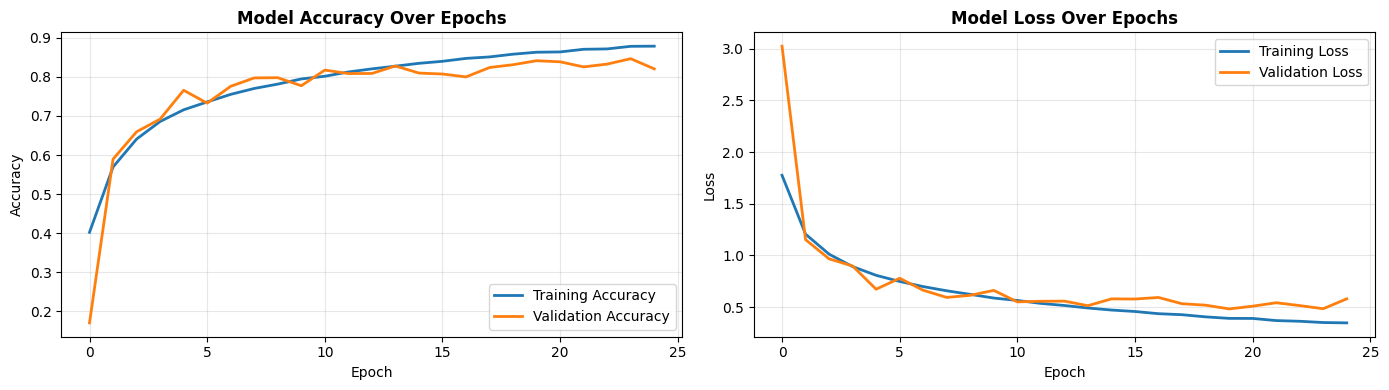

✓ Training curves plotted successfully!


In [18]:
# ═══════════════════════════════════════════════════════════════════
# VISUALIZE TRAINING HISTORY
# ═══════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Accuracy plot
axes[0].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[0].set_title('Model Accuracy Over Epochs', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss plot
axes[1].plot(history.history['loss'], label='Training Loss', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[1].set_title('Model Loss Over Epochs', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Training curves plotted successfully!")

In [19]:
# ═══════════════════════════════════════════════════════════════════
# EVALUATE MODEL ON TEST SET
# ═══════════════════════════════════════════════════════════════════

print("\nEvaluating model on test dataset...")
test_loss, test_accuracy = model.evaluate(X_test, y_test_cat, verbose=0)

print(f"\n{'='*50}")
print(f"TEST SET PERFORMANCE")
print(f"{'='*50}")
print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"{'='*50}")

# Get predictions
y_pred_probs = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_test_labels = np.argmax(y_test_cat, axis=1)

# Detailed classification report
print("\n✓ Classification Report:")
print(classification_report(y_test_labels, y_pred, target_names=class_names, zero_division=0))


Evaluating model on test dataset...

TEST SET PERFORMANCE
Test Loss:     0.5945
Test Accuracy: 0.8121 (81.21%)

✓ Classification Report:
              precision    recall  f1-score   support

    airplane       0.88      0.77      0.82      1000
  automobile       0.90      0.93      0.92      1000
        bird       0.81      0.70      0.75      1000
         cat       0.73      0.60      0.66      1000
        deer       0.69      0.89      0.78      1000
         dog       0.82      0.70      0.76      1000
        frog       0.68      0.95      0.79      1000
       horse       0.94      0.79      0.86      1000
        ship       0.86      0.92      0.89      1000
       truck       0.92      0.86      0.89      1000

    accuracy                           0.81     10000
   macro avg       0.82      0.81      0.81     10000
weighted avg       0.82      0.81      0.81     10000



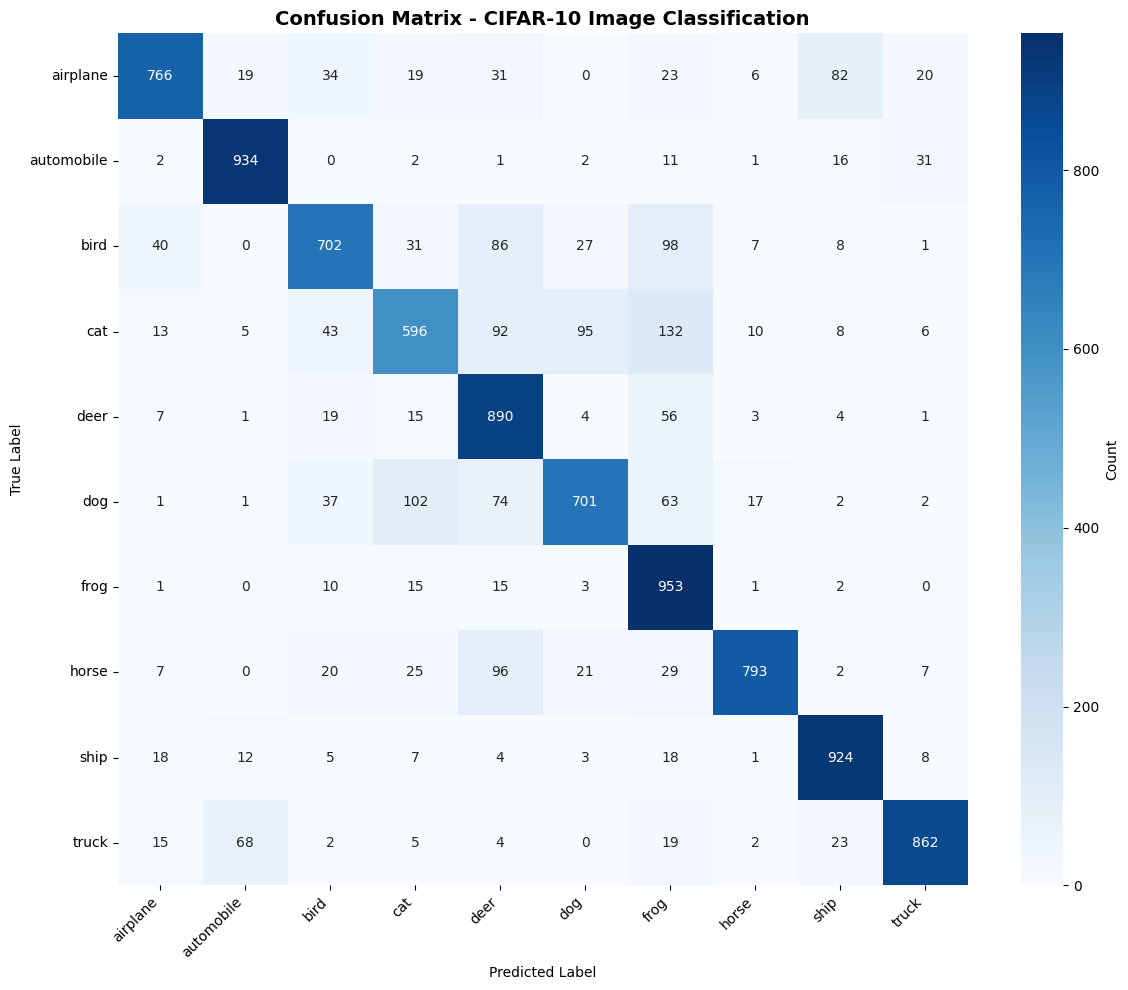

✓ Confusion matrix plotted successfully!


In [20]:
# ═══════════════════════════════════════════════════════════════════
# CONFUSION MATRIX VISUALIZATION
# ═══════════════════════════════════════════════════════════════════

cm = confusion_matrix(y_test_labels, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names, 
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - CIFAR-10 Image Classification', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("✓ Confusion matrix plotted successfully!")

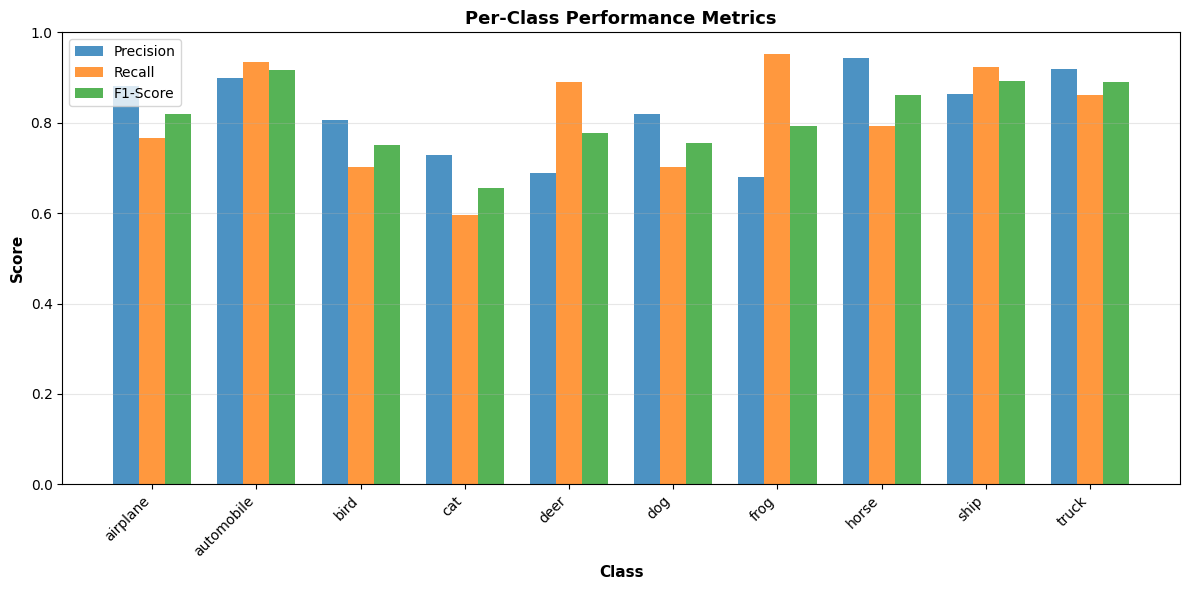

✓ Per-class metrics visualization completed!


In [21]:
# ═══════════════════════════════════════════════════════════════════
# PER-CLASS PERFORMANCE METRICS
# ═══════════════════════════════════════════════════════════════════

from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = precision_recall_fscore_support(
    y_test_labels, y_pred, average=None, zero_division=0
)

# Create visualization
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(class_names))
width = 0.25

ax.bar(x - width, precision, width, label='Precision', alpha=0.8)
ax.bar(x, recall, width, label='Recall', alpha=0.8)
ax.bar(x + width, f1, width, label='F1-Score', alpha=0.8)

ax.set_xlabel('Class', fontsize=11, fontweight='bold')
ax.set_ylabel('Score', fontsize=11, fontweight='bold')
ax.set_title('Per-Class Performance Metrics', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

print("✓ Per-class metrics visualization completed!")

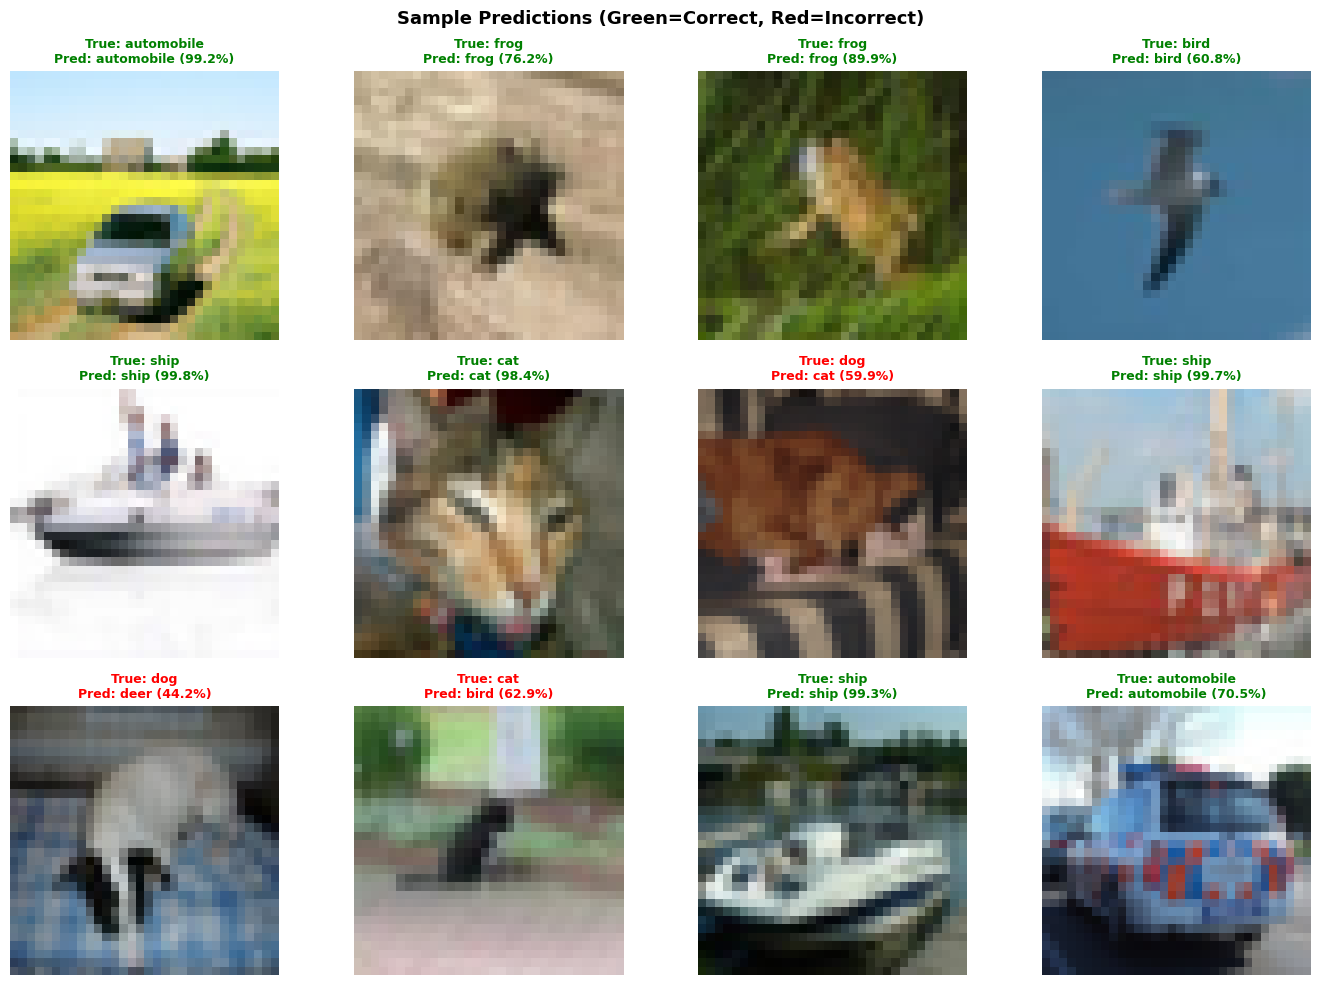

✓ Sample predictions displayed!


In [22]:
# ═══════════════════════════════════════════════════════════════════
# SAMPLE PREDICTIONS VISUALIZATION
# ═══════════════════════════════════════════════════════════════════

# Select 12 random test images
indices = np.random.choice(len(X_test), 12, replace=False)

fig, axes = plt.subplots(3, 4, figsize=(14, 10))
axes = axes.ravel()

for i, idx in enumerate(indices):
    image = X_test[idx]
    true_label = class_names[y_test_labels[idx]]
    pred_label = class_names[y_pred[idx]]
    confidence = y_pred_probs[idx].max() * 100
    
    # Plot image
    axes[i].imshow(image)
    
    # Color: green if correct, red if incorrect
    color = 'green' if y_test_labels[idx] == y_pred[idx] else 'red'
    
    axes[i].set_title(f'True: {true_label}\nPred: {pred_label} ({confidence:.1f}%)', 
                     color=color, fontweight='bold', fontsize=9)
    axes[i].axis('off')

plt.suptitle('Sample Predictions (Green=Correct, Red=Incorrect)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("✓ Sample predictions displayed!")

In [23]:
# ═══════════════════════════════════════════════════════════════════
# PROJECT SUMMARY
# ═══════════════════════════════════════════════════════════════════

print("\n" + "="*60)
print(" "*15 + "CNN IMAGE CLASSIFICATION - PROJECT SUMMARY")
print("="*60)
print("\n📊 DATASET INFORMATION:")
print(f"   • Dataset: CIFAR-10 (10 object classes)")
print(f"   • Training samples: {len(X_train)}")
print(f"   • Test samples: {len(X_test)}")
print(f"   • Image size: 32x32x3")
print(f"   • Classes: {', '.join(class_names)}")

print("\n🏗️  MODEL ARCHITECTURE:")
print(f"   • Type: Convolutional Neural Network (CNN)")
print(f"   • Convolutional blocks: 3")
print(f"   • Filters progression: 32→64→128")
print(f"   • Total parameters: {model.count_params():,}")

print("\n📈 TRAINING CONFIGURATION:")
print(f"   • Optimizer: Adam")
print(f"   • Learning rate: 0.001")
print(f"   • Epochs: 25")
print(f"   • Batch size: 128")
print(f"   • Regularization: Dropout, Batch Normalization")

print("\n✅ PERFORMANCE METRICS:")
print(f"   • Test Accuracy: {test_accuracy*100:.2f}%")
print(f"   • Test Loss: {test_loss:.4f}")
print(f"   • Best validation accuracy: {max(history.history['val_accuracy'])*100:.2f}%")

print("\n✨ KEY FEATURES:")
print(f"   ✓ Fully functional CNN model trained on CIFAR-10")
print(f"   ✓ Comprehensive evaluation on test dataset")
print(f"   ✓ Training history visualization")
print(f"   ✓ Confusion matrix analysis")
print(f"   ✓ Per-class performance metrics")
print(f"   ✓ Sample predictions with confidence scores")

print("\n" + "="*60)
print("✨ PROJECT COMPLETED SUCCESSFULLY! ✨")
print("="*60 + "\n")


               CNN IMAGE CLASSIFICATION - PROJECT SUMMARY

📊 DATASET INFORMATION:
   • Dataset: CIFAR-10 (10 object classes)
   • Training samples: 50000
   • Test samples: 10000
   • Image size: 32x32x3
   • Classes: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck

🏗️  MODEL ARCHITECTURE:
   • Type: Convolutional Neural Network (CNN)
   • Convolutional blocks: 3
   • Filters progression: 32→64→128
   • Total parameters: 1,325,738

📈 TRAINING CONFIGURATION:
   • Optimizer: Adam
   • Learning rate: 0.001
   • Epochs: 25
   • Batch size: 128
   • Regularization: Dropout, Batch Normalization

✅ PERFORMANCE METRICS:
   • Test Accuracy: 81.21%
   • Test Loss: 0.5945
   • Best validation accuracy: 84.64%

✨ KEY FEATURES:
   ✓ Fully functional CNN model trained on CIFAR-10
   ✓ Comprehensive evaluation on test dataset
   ✓ Training history visualization
   ✓ Confusion matrix analysis
   ✓ Per-class performance metrics
   ✓ Sample predictions with confidence scores

✨ PRO